In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## Climatic Conditions in Bavaria and Staatsforsten Study Areas

In [2]:
import ee
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

ee.Authenticate()
PROJECT_NAME='xxx'
ee.Initialize(PROJECT_NAME)

ASSET="xxx" # insert path
bayern = ee.FeatureCollection(ASSET)

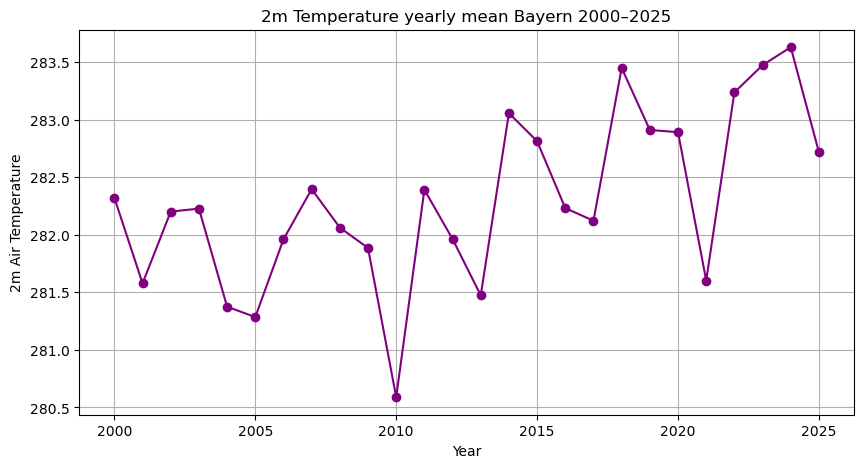

In [3]:
## ERA5 2m Air Temperature Plot Bavaria - 2000 to 2025



# ERA5 data
Temp2m = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['temperature_2m']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = start.advance(1, 'year')
    mean = Temp2m.filterDate(start, end).mean()
    value = mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=11132
    ).get('temperature_2m')
    return value

    
years = list(range(2000, 2026))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='purple')
plt.xlabel("Year")
plt.ylabel("2m Air Temperature")
plt.title("2m Temperature yearly mean Bayern 2000–2025")
plt.grid(True)
plt.show()

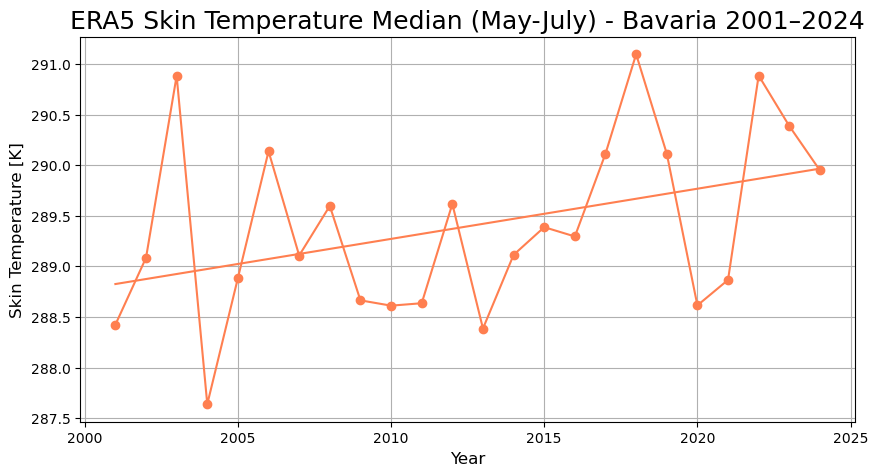

In [4]:
## ERA5 Skin Temperature Growing Season Bavaria - 2001 to 2024


# ERA5 data
SkinTemp = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['skin_temperature']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    median = SkinTemp.filterDate(start, end).median()

    value = median.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale=SkinTemp.first().projection().nominalScale()
    ).get('skin_temperature')
    return value

    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)

reg_years = np.array(years)
reg_val = np.array(values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='coral')
plt.plot(reg_years, trend, '-', color='coral')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Skin Temperature [K]", fontsize=12)
plt.title("ERA5 Skin Temperature Median (May-July) - Bavaria 2001–2024", fontsize=18)
plt.grid(True)
plt.show()

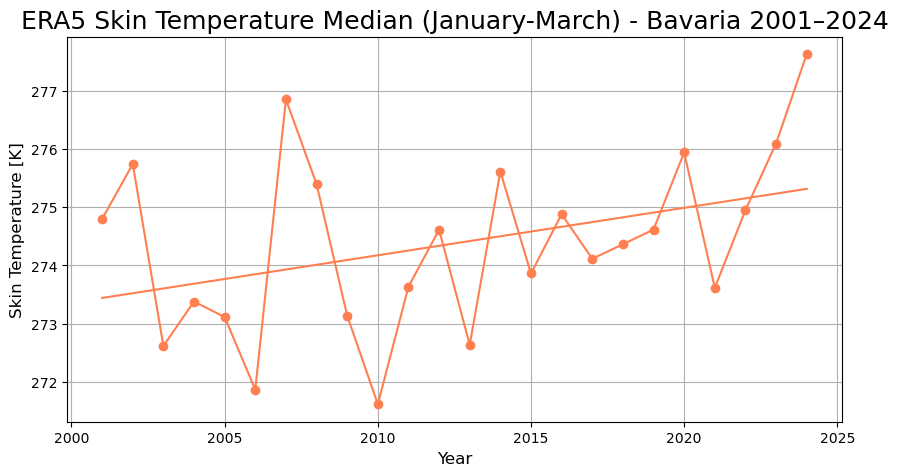

In [5]:
## ERA5 Skin Temperature Winter Season Bavaria - 2001 to 2024


# ERA5 data
SkinTemp = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['skin_temperature']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 4, 1)

    median = SkinTemp.filterDate(start, end).median()

    value = median.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale=SkinTemp.first().projection().nominalScale()
    ).get('skin_temperature')
    return value

    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)

reg_years = np.array(years)
reg_val = np.array(values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='coral')
plt.plot(reg_years, trend, '-', color='coral')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Skin Temperature [K]", fontsize=12)
plt.title("ERA5 Skin Temperature Median (January-March) - Bavaria 2001–2024", fontsize=18)
plt.grid(True)
plt.show()

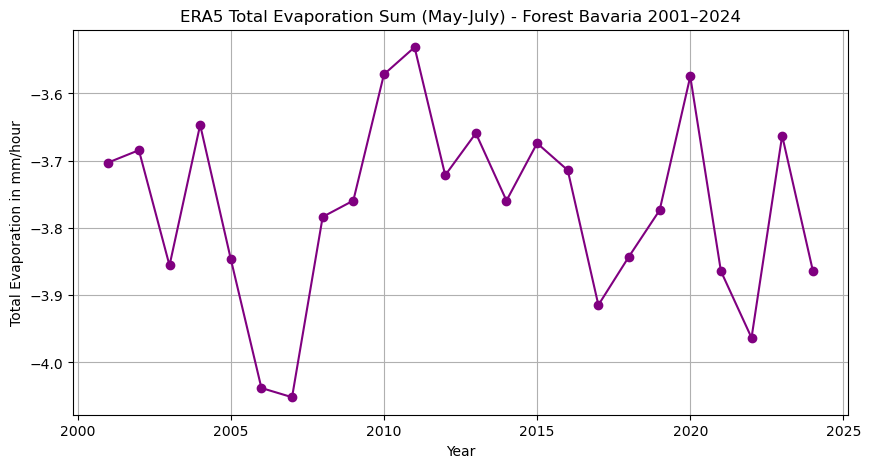

In [7]:
## ERA5 Total Evaporation Sum Growing Season Bayern - 2001 to 2024


# ERA5 data
EvapoTotal = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['total_evaporation']))



def yearly_mean(year):
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    mean = EvapoTotal.filterDate(start, end).sum()

    value = mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=EvapoTotal.first().projection().nominalScale()
    ).get('total_evaporation')
    return value



years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='purple')
plt.xlabel("Year")
plt.ylabel("Total Evaporation in mm/hour")
plt.title("ERA5 Total Evaporation Sum (May-July) - Bavaria 2001–2024")
plt.grid(True)
plt.show()

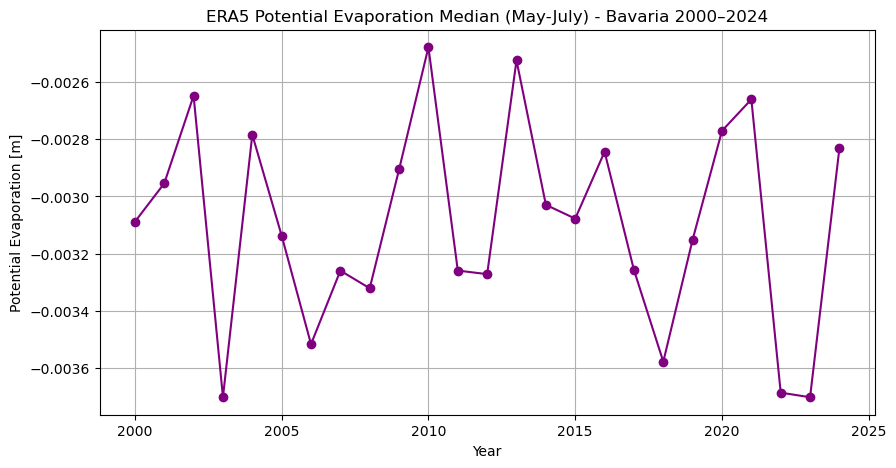

In [8]:
## ERA5 Potential Evaporation Median Bavaria - 2001 bis 2024


# ERA5 data
EvapoPot = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['potential_evaporation']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    median = EvapoPot.filterDate(start, end).median()

    value = median.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=bayern.geometry(),
        scale=EvapoPot.first().projection().nominalScale()
    ).get('potential_evaporation')

    return value

    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='purple')
plt.xlabel("Year")
plt.ylabel("Potential Evaporation [m]")
plt.title("ERA5 Potential Evaporation Median (May-July) - Bavaria 2001–2024")
plt.grid(True) 
plt.show()

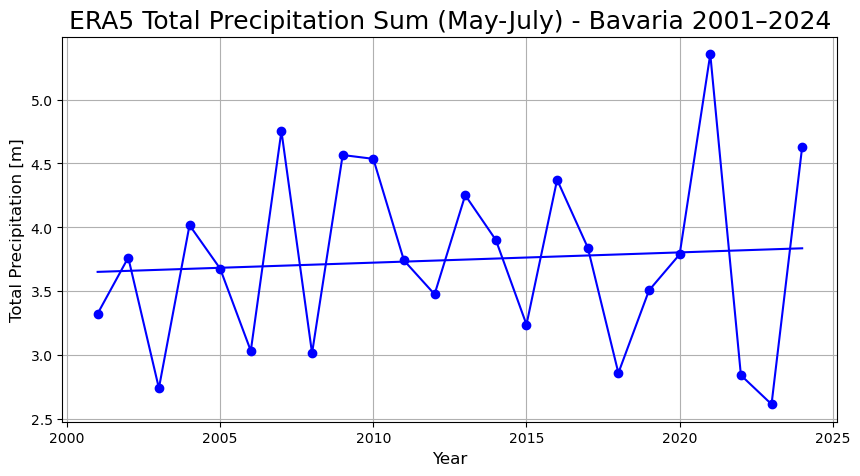

In [6]:
## ERA5 Total Precipitation Growing Season Sum Bavaria - 2001 to 2024


# ERA5 data
Precip = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['total_precipitation']))



def yearly_mean(year):
    start = ee.Date.fromYMD(year, 5, 1)
    end   = ee.Date.fromYMD(year, 8, 1)

    total = Precip.filterDate(start, end).sum()

    value = total.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=Precip.first().projection().nominalScale()
    ).get('total_precipitation')

    return value


    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)

reg_years = np.array(years)
reg_val = np.array(values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='blue')
plt.plot(reg_years, trend, '-', color='blue')

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Precipitation [m]", fontsize=12)
plt.title("ERA5 Total Precipitation Sum (May-July) - Bavaria 2001–2024", fontsize=18)
plt.grid(True) 
plt.show()

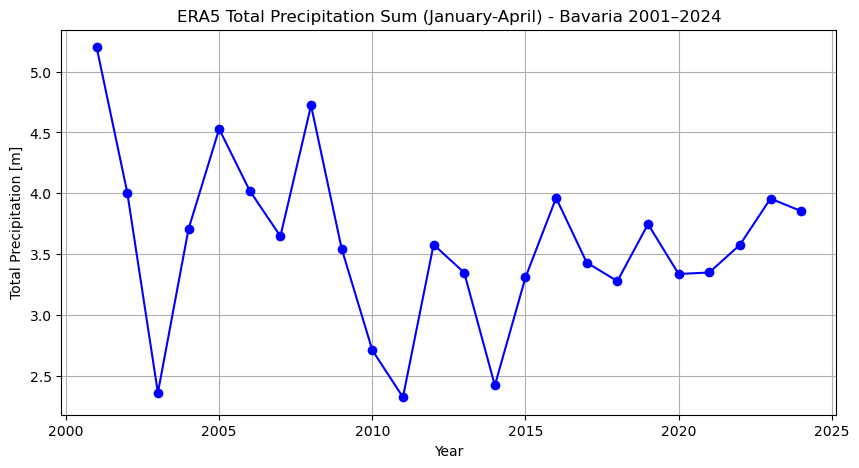

In [2]:
## ERA5 Total Precipitation Sum (January to April) Bavaria - 2001 to 2024


# ERA5 data
Precip = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['total_precipitation']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 5, 1)

    total = Precip.filterDate(start, end).sum()

    value = total.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=Precip.first().projection().nominalScale()
    ).get('total_precipitation')

    return value


    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='blue')
plt.xlabel("Year")
plt.ylabel("Total Precipitation [m]")
plt.title("ERA5 Total Precipitation Sum (January-April) - Bavaria 2001–2024")
plt.grid(True) 
plt.show()

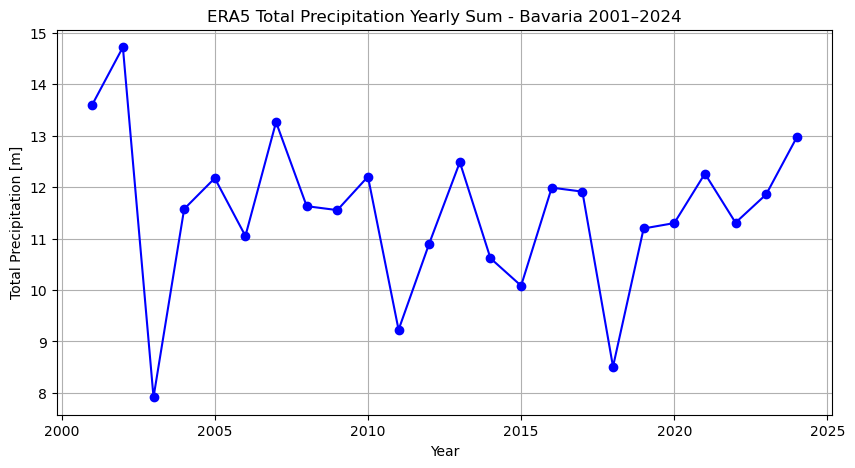

In [8]:
## ERA5 Total Precipitation Yearly Sum Bavaria - 2001 to 2024


# ERA5 data
Precip = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['total_precipitation']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 1)

    total = Precip.filterDate(start, end).sum()

    value = total.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=Precip.first().projection().nominalScale()
    ).get('total_precipitation')

    return value


    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)


# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='blue')
plt.xlabel("Year")
plt.ylabel("Total Precipitation [m/pixel]")
plt.title("ERA5 Total Precipitation Yearly Sum - Bavaria 2001–2024")
plt.grid(True) 
plt.show()

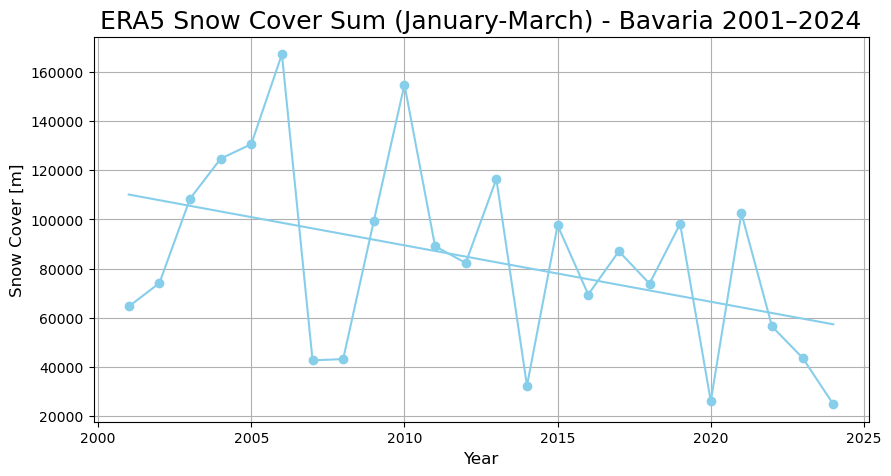

In [4]:
## ERA5 Snow Cover Winter Season Bavaria - 2001 to 2024


# ERA5 Daten laden
Snow = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
       .filterBounds(bayern)
       .select(['snow_cover']))

def yearly_mean(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 4, 1)

    median = Snow.filterDate(start, end).sum()

    value = median.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=bayern.geometry(),
        scale=Snow.first().projection().nominalScale()
    ).get('snow_cover')

    return value


    
years = list(range(2001, 2025))
values=[]


for y in years:
    v= yearly_mean(y).getInfo()
    values.append(v)

reg_years = np.array(years)
reg_val = np.array(values)

slope, intercept = np.polyfit(reg_years, reg_val,1)
trend = slope * reg_years + intercept

# Plot
plt.figure(figsize=(10,5))
plt.plot(years, values, marker='o', color='skyblue')
plt.plot(reg_years, trend, '-', color='skyblue')

plt.xlabel("Year", fontsize=12)
plt.ylabel("Snow Cover [m]", fontsize=12)
plt.title("ERA5 Snow Cover Sum (January-March) - Bavaria 2001–2024", fontsize=18)
plt.grid(True) 
plt.show()

In [3]:
# Test

DWD_Data="xxx" # insert path
DATA_DIR = Path(DWD_Data)

# Example temperature
csv_file = DATA_DIR / "DWD_temperature.csv"

# Read CSV
df = pd.read_csv(
    csv_file,
    sep=",",           
    decimal=".",       
    na_values=[-999, "-999", ""]
)

print(df.columns)       # Column names
print(df.shape)         # number of lines and columns

Index(['Produkt_Code', 'SDO_ID', 'Zeitstempel', 'Wert', 'Qualitaet_Byte',
       'Qualitaet_Niveau'],
      dtype='object')
(717, 6)


In [4]:
df["SDO_ID"] = df["SDO_ID"].astype(str)
df["Wert"] = pd.to_numeric(df["Wert"], errors="coerce")
df["date"] = pd.to_datetime(df["Zeitstempel"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

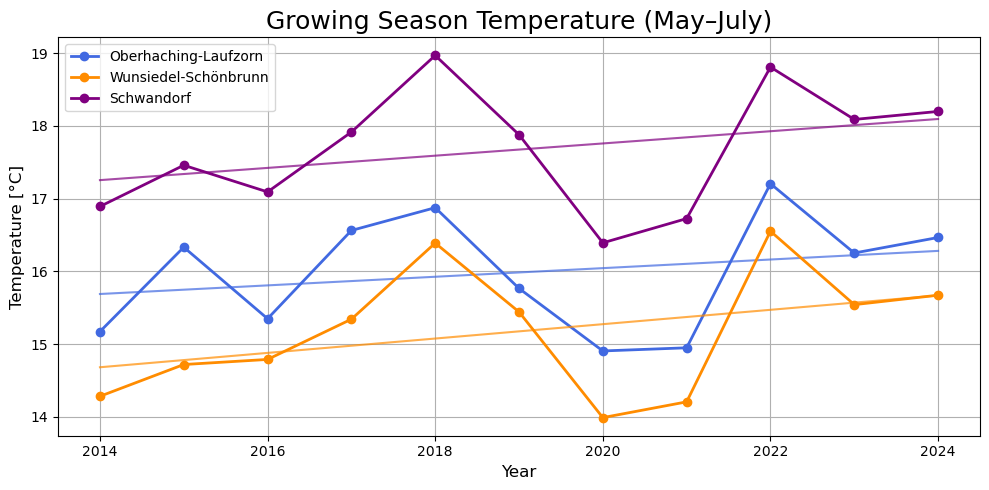

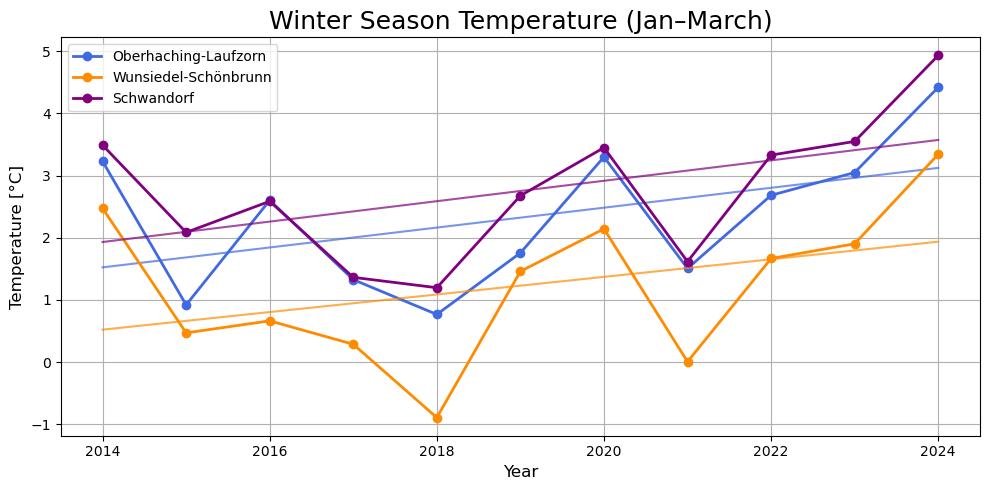

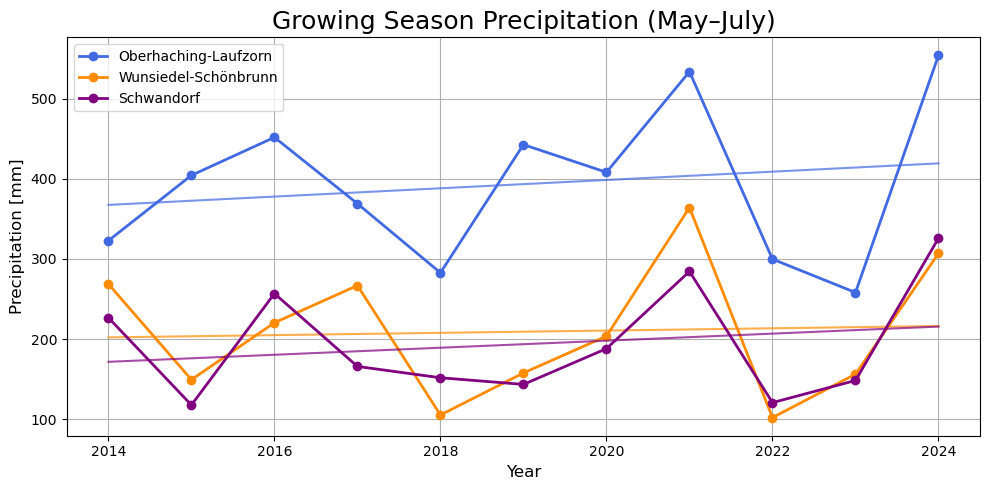

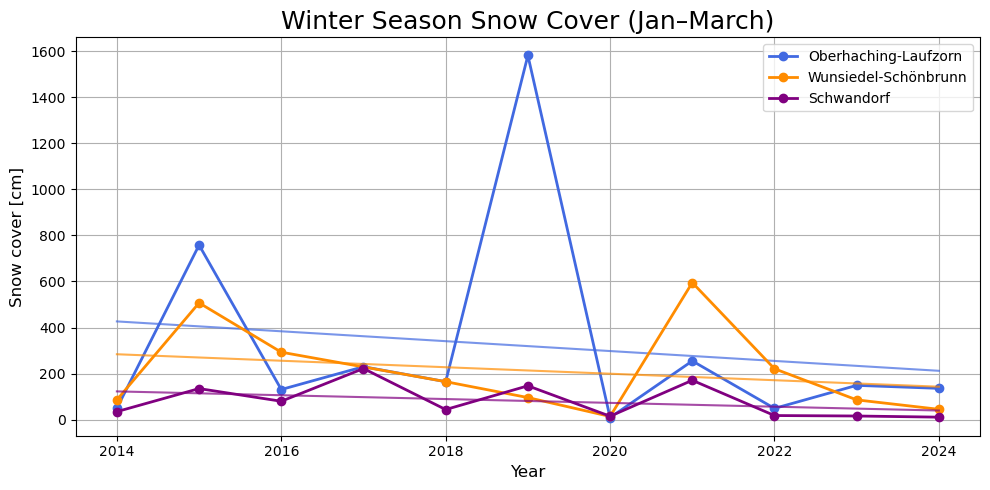

In [54]:
# Temperature, Precipitation and Snow Cover Plots for the DWD Stations - 2014 to 2024

DATA = Path(PATH)


START_YEAR = 2014
END_YEAR   = 2024

STATIONS = {
    "7431": ("Oberhaching-Laufzorn", "royalblue"),
    "7394": ("Wunsiedel-Schönbrunn", "darkorange"),
    "4592": ("Schwandorf", "purple")
}

# Load CSV
def load_dwd_csv(filename):
    df = pd.read_csv(
        DATA / filename,
        sep=",",
        decimal=".",
        index_col=0
    )

    df = df.rename(columns={
        "Produkt_Code": "station_id",
        "SDO_ID": "date",
        "Zeitstempel": "value"
    })

    df["station_id"] = df["station_id"].astype(str)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month

    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]

    return df

temp = load_dwd_csv("DWD_temperature.csv")
prec = load_dwd_csv("DWD_precipitation.csv")
snow = load_dwd_csv("DWD_snowcover.csv")

# Multi-station plot
def plot_multi_station(series_dict, title, ylabel, fname):
    plt.figure(figsize=(10, 5))

    for sid, (label, color) in STATIONS.items():
        s = series_dict.get(sid, pd.Series(dtype=float)).dropna()
        if len(s) < 2:
            continue

        x = s.index.values
        y = s.values

        # Time series
        plt.plot(x, y, marker="o", color=color, linewidth=2, label=label)

        # Trend line
        coef = np.polyfit(x, y, 1)
        trend = np.poly1d(coef)
        plt.plot(x, trend(x), linestyle="-", color=color, alpha=0.7)

    plt.title(title, fontsize=18)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# Growing season temperature
gs_temp = {}
for sid in STATIONS:
    df = temp[temp["station_id"] == sid]
    gs = df[df["month"].between(5, 7)]
    gs_temp[sid] = gs.groupby("year")["value"].mean()

plot_multi_station(gs_temp, "Growing Season Temperature (May–July)", "Temperature [°C]", "GS_temperature_all_stations.png")

# Winter season temperature
ws_temp = {}
for sid in STATIONS:
    df = temp[temp["station_id"] == sid]
    ws = df[df["month"].between(1, 3)]
    ws_temp[sid] = ws.groupby("year")["value"].mean()

plot_multi_station(ws_temp, "Winter Season Temperature (Jan–March)", "Temperature [°C]", "WS_temperature_all_stations.png")

# Growing season precipitation
gs_prec = {}
for sid in STATIONS:
    df = prec[prec["station_id"] == sid]
    gs = df[df["month"].between(5, 7)]
    gs_prec[sid] = gs.groupby("year")["value"].sum()

plot_multi_station(gs_prec, "Growing Season Precipitation (May–July)", "Precipitation [mm]", "GS_precipitation_all_stations.png")

# Winter season snow cover
ws_snow = {}
for sid in STATIONS:
    df = snow[snow["station_id"] == sid]
    ws = df[df["month"].between(1, 3)]
    ws_snow[sid] = ws.groupby("year")["value"].sum()

plot_multi_station(ws_snow, "Winter Season Snow Cover (Jan–March)", "Snow cover [cm]", "WS_snowcover_all_stations.png")
